In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [ ]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

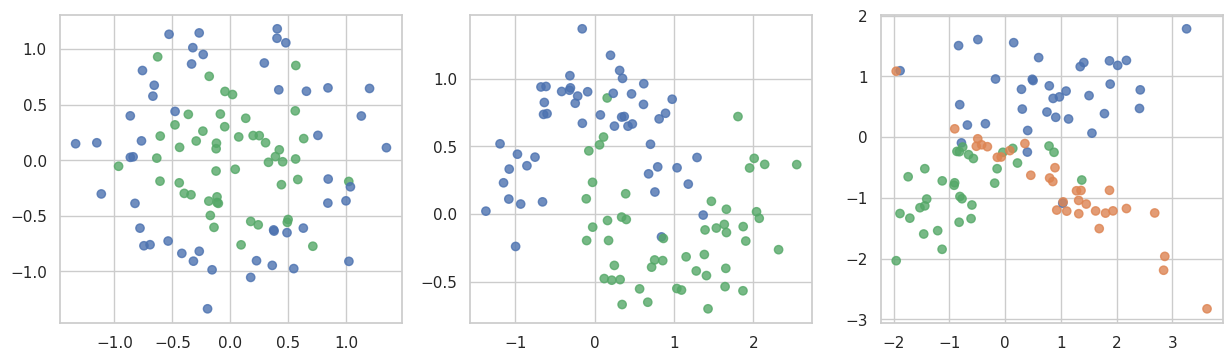

In [ ]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [ ]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

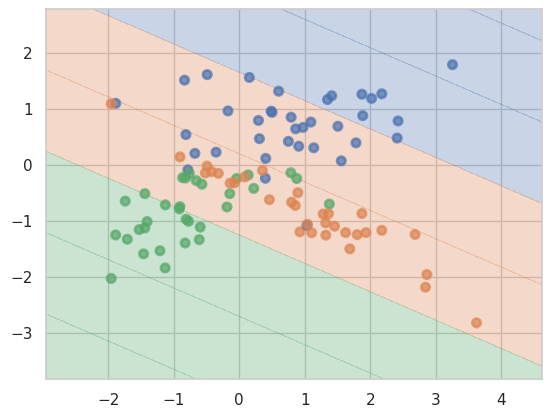

In [ ]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

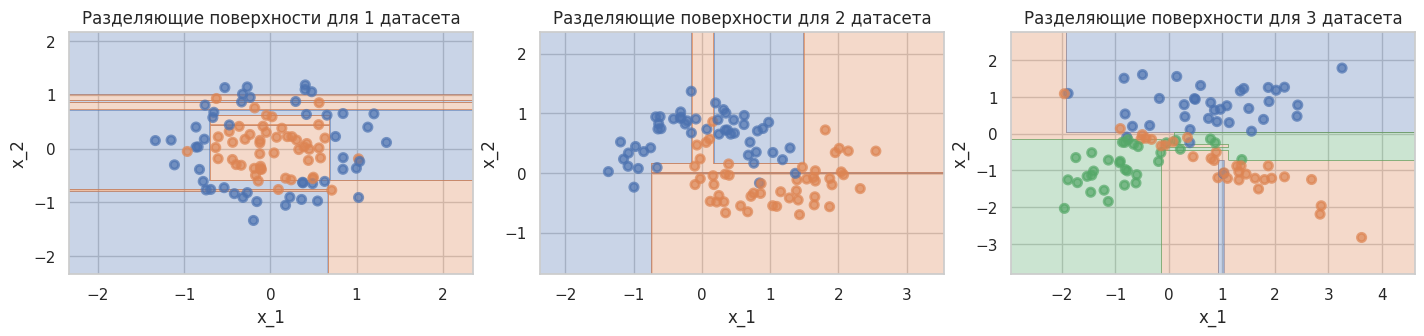

In [ ]:
plt.figure(figsize=(15, 4))
metrics = dict()

for i, dataset in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    X, y = dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
    dec_tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
    y_train_pred = dec_tree.predict(X_train)
    y_test_pred = dec_tree.predict(X_test)
    acc_train = (y_train_pred == y_train).sum() / len(y_train)
    acc_test= (y_test_pred == y_test).sum() / len(y_test)
    metrics[f'dataset_{i + 1}'] = (acc_train, acc_test)
    plot_surface(dec_tree, X, y)
    plt.title(f'Разделяющие поверхности для {i + 1} датасета')
    plt.xlabel('x_1')
    plt.ylabel('x_2')

In [ ]:
for keys in metrics.keys():
    print(f'Accuracy on train and test on {keys}: {metrics[keys]}')

Accuracy on train and test on dataset_1: (1.0, 0.7333333333333333)
Accuracy on train and test on dataset_2: (1.0, 0.8666666666666667)
Accuracy on train and test on dataset_3: (1.0, 0.8333333333333334)


__Ответ:__ деревья переобучились, так как accuracy на трейне равен 1, то есть деревья полностью подогнались под трейн, не смотря на хорошие показатели на тесте (на реальных данных скорее показатели будут ниже), это видно и по разделяющим поверхностям: почти под каждый объект (скорее трейновский) выделяется своя область.

__Задание 2. (1.25 баллов)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?


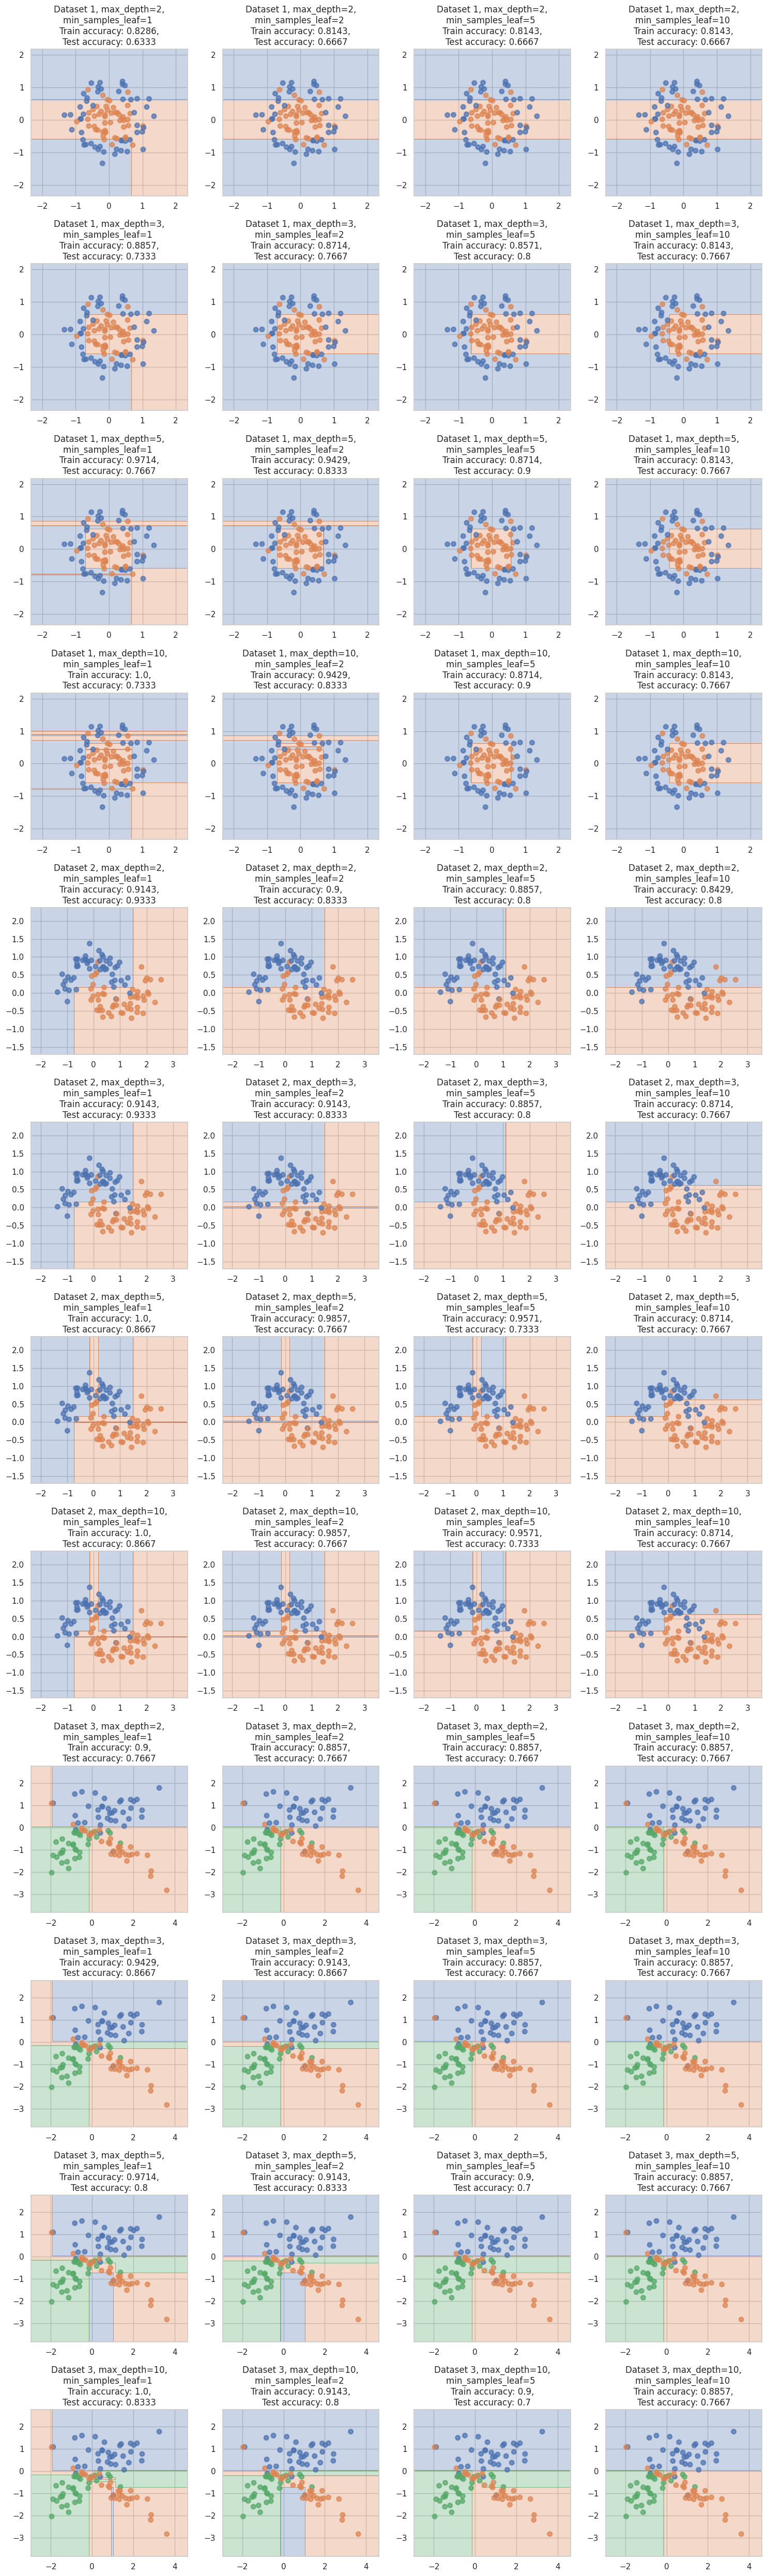

In [ ]:
from sklearn.model_selection import GridSearchCV
plt.figure(figsize=(15, 50))
param_grid = {
    'max_depth': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}
j = 1
for i, dataset in enumerate(datasets):
    X, y = dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
    for depth in param_grid['max_depth']:
        for leaf in param_grid['min_samples_leaf']:

            plt.subplot(12, 4, j)

            clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf, random_state=42)
            clf.fit(X_train, y_train)

            y_train_pred = clf.predict(X_train)
            y_test_pred = clf.predict(X_test)

            acc_train = (y_train_pred == y_train).sum() / len(y_train)
            acc_test = (y_test_pred == y_test).sum() / len(y_test)

            plot_surface(clf, X, y)
            plt.title(f'Dataset {i + 1}, max_depth={depth},\nmin_samples_leaf={leaf} \nTrain accuracy: {round(acc_train, 4)},\nTest accuracy: {round(acc_test, 4)}')
            j += 1
plt.tight_layout()
plt.show()

__Ответ:__ При увеличении параметра max_depth при фиксированном втором параметре дерево становится более сложным и сильнее подгоняется под трейн, появляются области, выделенные под "выбросы". Это характерно для всех датасетов, но при небольшом значении min_samples_leaf, так как второй действует в противоположном направлении.

Параметр min_samples_leaf: при увеличении значения разделяющая поверхность сглаживается, так как дерево становится менее склонным к переобучению.

max_depth отвечает за максимальную глубину дерева, а чем глубже дерево, тем больше можно выделить областей под объекты. При очень большом значении дерево в теории может выделить область под каждый объект. При этом слишком маленькое значение ведет к недообучению.

min_samples_leaf отвечает за минимальное количество объектов в листе. Такая же история: если будет очень маленькое, то можно для каждого объекта выделить лист (то есть область), и жестко переобучиться. Если слишком большое значение - можно недообучиться.

Оптимальные значения, при которых у дерева хорошая обучающая способность (то есть и на трейне, и на тесте примерно одинаковые высокие значения accuracy) лежит где-то между крайностями.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw5code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу [students.csv](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/homeworks-practice/homework-practice-05-trees/students.csv) (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

In [ ]:
! wget https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2022-fall/homeworks-practice/homework-practice-05-trees/students.csv

--2024-12-11 14:07:47--  https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2022-fall/homeworks-practice/homework-practice-05-trees/students.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7249 (7.1K) [text/plain]
Saving to: ‘students.csv’

students.csv        100%[===================>]   7.08K  --.-KB/s    in 0s      

2024-12-11 14:07:47 (69.4 MB/s) - ‘students.csv’ saved [7249/7249]



In [ ]:
df = pd.read_csv('students.csv')
df.head()

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0


In [ ]:
y = df['UNS']
X = df.drop('UNS', axis=1)

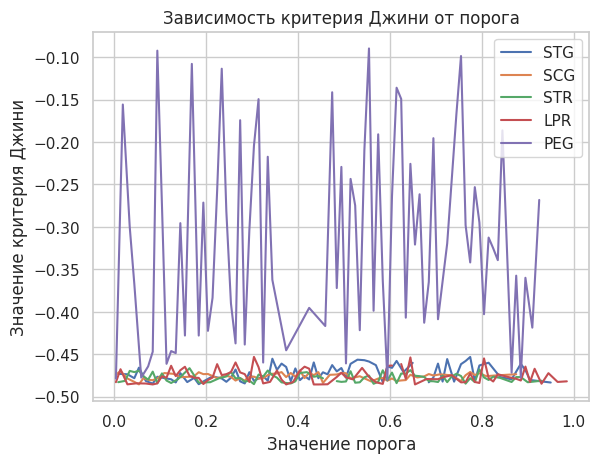

In [ ]:
from hw5code import find_best_split
for feature in X.columns:
    spl = find_best_split(X[feature], y)
    thresholds = spl[0]
    ginis = spl[1]
    plt.plot(thresholds, ginis)
plt.title('Зависимость критерия Джини от порога')
plt.xlabel('Значение порога')
plt.ylabel('Значение критерия Джини')
plt.legend(X.columns);

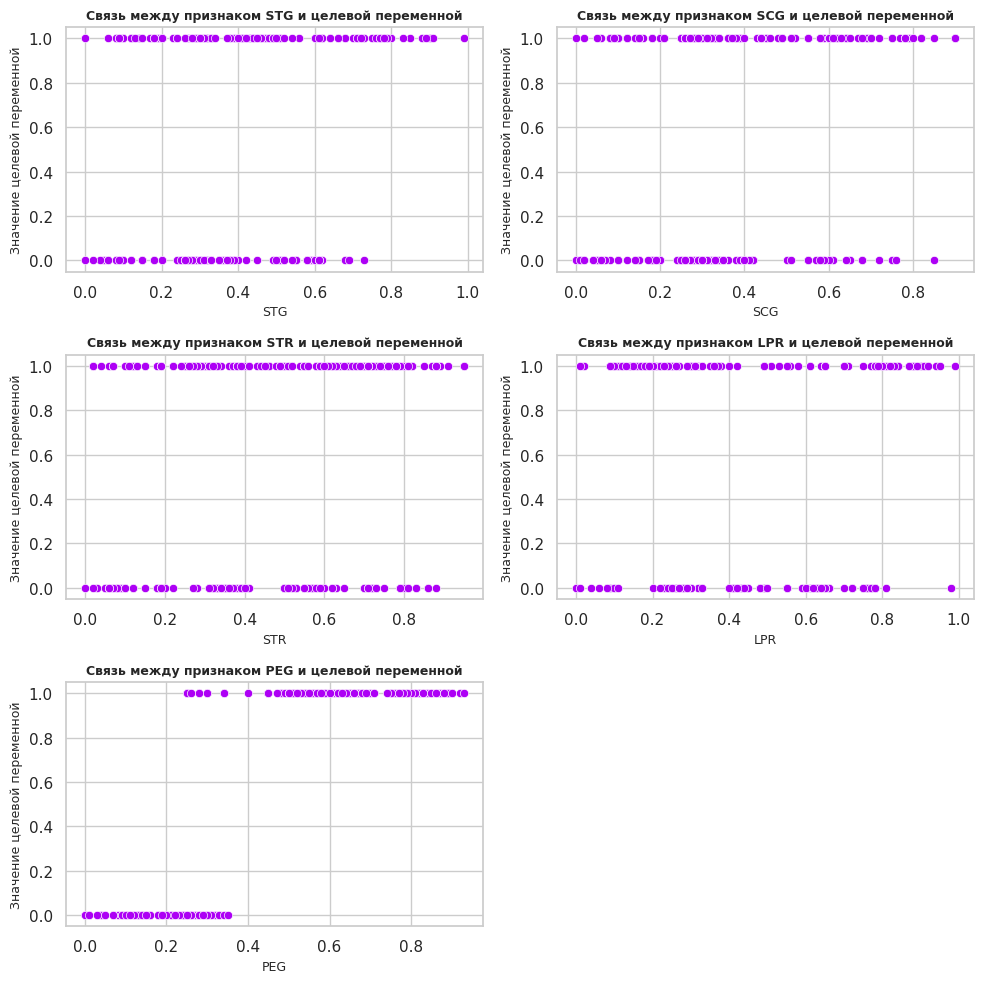

In [ ]:
from matplotlib import gridspec
import itertools
fig = plt.figure(figsize = (10, 10))
gr = gridspec.GridSpec(3, 2)
features = X.columns
for feature, grd in zip(features, itertools.product([0, 1, 2], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.scatterplot(x=X[feature], y=y, color='#AD00F5')
    ax.set_title(f'Связь между признаком {feature} и целевой переменной', fontsize = 9, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 9)
    ax.set_ylabel('Значение целевой переменной', fontsize = 9)
fig.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** Самым лучшим признаком для разбиения является PEG, так как при разбиении по нему достигается максимальное значение изменения (а точнее увеличения) критерия информативности. Хоть и значения довольно волатильны, есть возможность добиться улучшения. У других признаков диапазон изменения критерия информативности маленький.

С scatter-графиками это согласуется, так как на ней видно четкое разделение на два класса по признаку PEG, практически идеально часть данных с таргетом ноль лежит в левой части, а с таргетом 1 - в правой. Поэтому деревьям легко разделить объекты по данному признаку, по другим такого разделения не наблюдается.

Вид кривой для хорошего признака выглядит как ломаная кривая с большим разбросом значений. От остальных отличается лишь этим разбросом.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw5code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture07-trees.pdf) в разделе «Построение дерева». Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:
!wget https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2023-fall/homeworks-practice/homework-practice-05-trees/agaricus-lepiota.data

--2024-12-11 14:07:49--  https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2023-fall/homeworks-practice/homework-practice-05-trees/agaricus-lepiota.data
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 373704 (365K) [text/plain]
Saving to: ‘agaricus-lepiota.data’

agaricus-lepiota.da 100%[===================>] 364.95K  --.-KB/s    in 0.007s  

2024-12-11 14:07:49 (53.1 MB/s) - ‘agaricus-lepiota.data’ saved [373704/373704]



In [ ]:
df = pd.read_csv('agaricus-lepiota.data')
df.head()

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


In [ ]:
X = df.drop('p', axis=1)
y = (df['p'] == 'e') * 1

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1, shuffle=True)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
X_train_enc = enc.fit_transform(X_train)
X_test_enc = enc.transform(X_test)

In [ ]:
import hw5code

In [ ]:
tree = hw5code.DecisionTree(['categorical'] * X.shape[1])
tree.fit(X_train_enc, y_train.values)
y_test_pred = tree.predict(X_test_enc)

In [ ]:
accuracy = (y_test_pred == y_test).sum() / len(y_test)
print(f'Accuracy: {accuracy}')

Accuracy: 1.0


__Задание 8. (1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe.

In [ ]:
!wget https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2024-fall/homework-practice/homework-practice-05-trees/tic-tac-toe-endgame.csv

--2024-12-11 16:32:52--  https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2024-fall/homework-practice/homework-practice-05-trees/tic-tac-toe-endgame.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25897 (25K) [text/plain]
Saving to: ‘tic-tac-toe-endgame.csv.1’

tic-tac-toe-endgame 100%[===================>]  25.29K  --.-KB/s    in 0.001s  

2024-12-11 16:32:52 (20.7 MB/s) - ‘tic-tac-toe-endgame.csv.1’ saved [25897/25897]



In [ ]:
data = pd.read_csv('tic-tac-toe-endgame.csv')
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


In [ ]:
import hw5code

In [ ]:
X = data.drop('V10', axis=1)
y = (data['V10'] == 'positive') * 1

In [ ]:
def plots_params(params, tree_param, X_train, y_train, X_test, y_test):
    accuracies = []
    for param in params:
        tree_params = {tree_param: param}
        clf = hw5code.DecisionTree(feature_types=["categorical"] * X_train.shape[1], **tree_params)
        clf.fit(X_train, y_train)
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)
        acc_test = (y_test_pred == y_test).sum() / len(y_test)
        accuracies.append(acc_test)

    plt.plot(params, accuracies)
    plt.xlabel(f'Значение параметра {tree_param}')
    plt.ylabel('Accuracy')
    plt.title(f'Зависимость качества предсказания от параметра {tree_param}')
    plt.show()

In [ ]:
param_grid = {
    'max_depth': [2, 3, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 7, 10, 15],
    'min_samples_split': [2, 3, 5, 7, 10, 15]

}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
X_train_enc = enc.fit_transform(X_train)
X_test_enc = enc.transform(X_test)

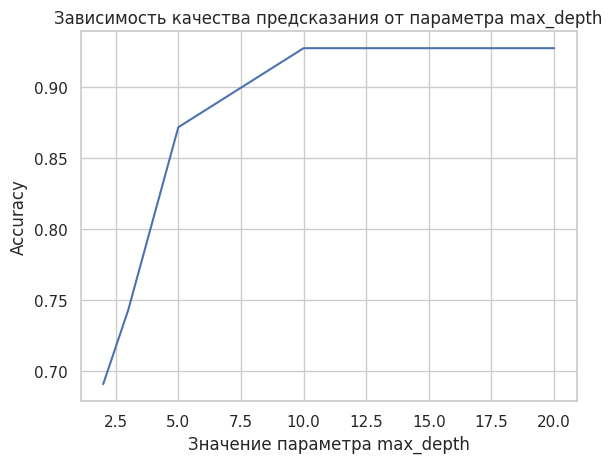

In [ ]:
plots_params(param_grid['max_depth'], 'max_depth', X_train_enc, y_train.values, X_test_enc, y_test)

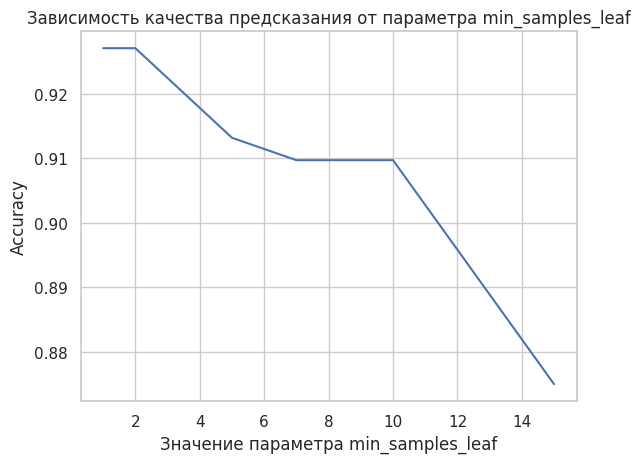

In [ ]:
plots_params(param_grid['min_samples_leaf'], 'min_samples_leaf', X_train_enc, y_train.values, X_test_enc, y_test)

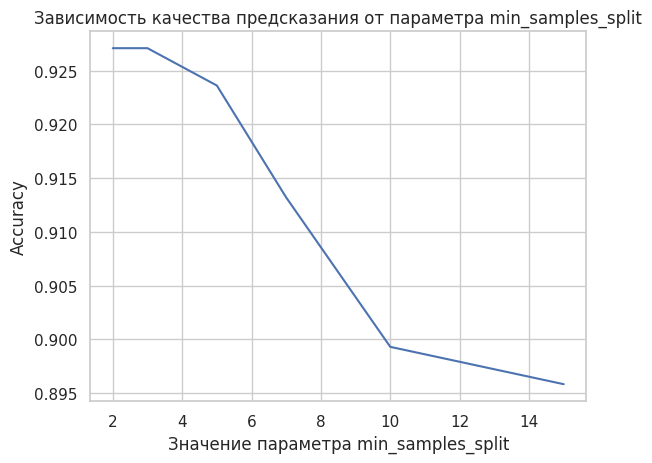

In [ ]:
plots_params(param_grid['min_samples_split'], 'min_samples_split', X_train_enc, y_train.values, X_test_enc, y_test)